# Pipeline OASIS-3 — De datos clínicos a splits listos para entrenar

Notebook completo que cubre todo el pipeline de preparación de datos OASIS-3:

- **Parte I** — Exploración clínica: carga CDR + demografía, etiquetado, análisis de distribución
- **Parte II** — Match MRI-Clínico: alineamiento temporal de sesiones MR con evaluaciones clínicas
- **Parte III** — Split Train/Val/Test: escaneo de NIfTIs descargados, cruce con ground truth, y partición estratificada a nivel de paciente (anti-leakage)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid")

BASE = Path(r"d:\clase\tfg\data\OASIS-4\Non-Imaging Data")
PATH_CDR  = BASE / r"UDSb4_Form B4_ Global Staging  CDR_ Standard and Supplemental\csv\OASIS3_UDSb4_cdr.csv"
PATH_DEMO = BASE / r"demo_demographics\csv\OASIS3_demographics.csv"

## 1. Carga y limpieza del archivo CDR

In [11]:
df_cdr_raw = pd.read_csv(PATH_CDR, low_memory=False)
print(f"Filas totales: {len(df_cdr_raw)}")
print(f"Columnas: {list(df_cdr_raw.columns)}")
df_cdr_raw.head(3)

Filas totales: 8626
Columnas: ['OASISID', 'OASIS_session_label', 'days_to_visit', 'age at visit', 'MMSE', 'memory', 'orient', 'judgment', 'commun', 'homehobb', 'perscare', 'CDRSUM', 'CDRTOT', 'dx1_code', 'dx2_code', 'dx3_code', 'dx4_code', 'dx5_code', 'dx1', 'dx2', 'dx3', 'dx4', 'dx5']


,OASISID,OASIS_session_label,days_to_visit,age at visit,MMSE,memory,orient,judgment,commun,homehobb,...,dx1_code,dx2_code,dx3_code,dx4_code,dx5_code,dx1,dx2,dx3,dx4,dx5
0,OAS30001,OAS30001_UDSb4_d0000,0,65.19,28.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
1,OAS30001,OAS30001_UDSb4_d0339,339,66.12,28.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
2,OAS30001,OAS30001_UDSb4_d0722,722,67.17,30.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.


In [12]:
cols_cdr = [
    'OASISID', 'days_to_visit', 'age at visit',
    'MMSE', 'CDRTOT', 'CDRSUM',
    'memory', 'orient', 'judgment', 'commun', 'homehobb', 'perscare',
    'dx1'
]
df_cdr = df_cdr_raw[cols_cdr].copy()

df_cdr = df_cdr.dropna(subset=['CDRTOT'])
print(f"Evaluaciones con CDR válido: {len(df_cdr)}")
print(f"\nValores únicos de CDRTOT: {sorted(df_cdr['CDRTOT'].unique())}")
print(f"\nDistribución de CDRTOT:")
print(df_cdr['CDRTOT'].value_counts().sort_index())

Evaluaciones con CDR válido: 8625

Valores únicos de CDRTOT: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Distribución de CDRTOT:
CDRTOT
0.0    6479
0.5    1444
1.0     528
2.0     155
3.0      19
Name: count, dtype: int64


## 2. Etiquetado (mismo mapeo que OASIS-1)

In [13]:
def map_label(cdr):
    if cdr == 0.0:
        return 0   # CN
    elif cdr == 0.5:
        return 1   # MCI
    elif cdr >= 1.0:
        return 2   # AD
    return None

df_cdr['label'] = df_cdr['CDRTOT'].apply(map_label)
df_cdr = df_cdr.dropna(subset=['label'])
df_cdr['label'] = df_cdr['label'].astype(int)

label_names = {0: 'CN', 1: 'MCI', 2: 'AD'}
df_cdr['label_name'] = df_cdr['label'].map(label_names)

print("Distribución tras etiquetado:")
print(df_cdr['label_name'].value_counts())

Distribución tras etiquetado:
label_name
CN     6479
MCI    1444
AD      702
Name: count, dtype: int64


## 3. Carga de demografía

In [14]:
df_demo_raw = pd.read_csv(PATH_DEMO, low_memory=False)
print(f"Sujetos en demografía: {len(df_demo_raw)}")
print(f"Columnas: {list(df_demo_raw.columns)}")
df_demo_raw.head(3)

Sujetos en demografía: 1378
Columnas: ['OASISID', 'Subject_accession', 'AgeatEntry', 'AgeatDeath', 'GENDER', 'EDUC', 'SES', 'racecode', 'race', 'ETHNIC', 'AIAN', 'NHPI', 'ASIAN', 'AA', 'WHITE', 'daddem', 'momdem', 'HAND', 'APOE']


,OASISID,Subject_accession,AgeatEntry,AgeatDeath,GENDER,EDUC,SES,racecode,race,ETHNIC,AIAN,NHPI,ASIAN,AA,WHITE,daddem,momdem,HAND,APOE
0,OAS30001,NaN,65.1945,NaN,2,12.0,4.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,R,23.0
1,OAS30002,NaN,67.2521,76.9397,1,18.0,2.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,R,34.0
2,OAS30003,NaN,58.8137,NaN,2,18.0,1.0,5,White,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,R,33.0


In [15]:
cols_demo = ['OASISID', 'AgeatEntry', 'GENDER', 'EDUC', 'race', 'APOE', 'HAND']
df_demo = df_demo_raw[cols_demo].copy()

df_demo['GENDER'] = df_demo['GENDER'].map({1: 'M', 2: 'F'})

# APOE: extraer si es portador del alelo e4 (factor de riesgo principal)
df_demo['APOE_e4'] = df_demo['APOE'].astype(str).str.contains('4').astype(int)

print(f"\nGénero:")
print(df_demo['GENDER'].value_counts())
print(f"\nPortadores APOE-e4: {df_demo['APOE_e4'].sum()} / {len(df_demo)} ({df_demo['APOE_e4'].mean()*100:.1f}%)")


Género:
GENDER
F    756
M    622
Name: count, dtype: int64

Portadores APOE-e4: 569 / 1378 (41.3%)


## 4. Unión: tabla maestra clínica

In [16]:
df_master = pd.merge(df_cdr, df_demo, on='OASISID', how='left')
df_master = df_master.sort_values(by=['OASISID', 'days_to_visit']).reset_index(drop=True)

print(f"Tabla maestra:")
print(f"  Evaluaciones totales: {len(df_master)}")
print(f"  Pacientes únicos:    {df_master['OASISID'].nunique()}")
print(f"  Columnas:            {len(df_master.columns)}")
print(f"\nPrimeras filas:")
df_master.head()

Tabla maestra:
  Evaluaciones totales: 8625
  Pacientes únicos:    1377
  Columnas:            22

Primeras filas:


,OASISID,days_to_visit,age at visit,MMSE,CDRTOT,CDRSUM,memory,orient,judgment,commun,...,dx1,label,label_name,AgeatEntry,GENDER,EDUC,race,APOE,HAND,APOE_e4
0,OAS30001,0,65.19,28.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Cognitively normal,0,CN,65.1945,F,12.0,White,23.0,R,0
1,OAS30001,339,66.12,28.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Cognitively normal,0,CN,65.1945,F,12.0,White,23.0,R,0
2,OAS30001,722,67.17,30.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Cognitively normal,0,CN,65.1945,F,12.0,White,23.0,R,0
3,OAS30001,1106,68.22,30.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Cognitively normal,0,CN,65.1945,F,12.0,White,23.0,R,0
4,OAS30001,1456,69.18,30.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Cognitively normal,0,CN,65.1945,F,12.0,White,23.0,R,0


## 5. Análisis de distribución

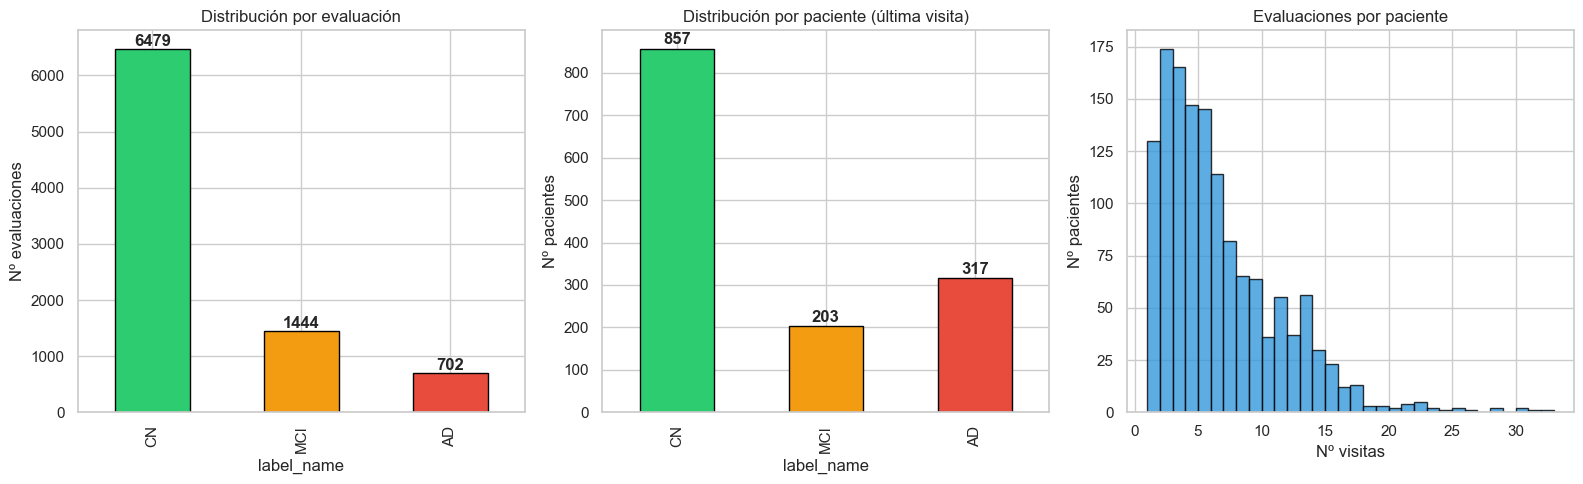

Visitas por paciente: media=6.3, mediana=5, max=32


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 5a. Distribución de clases (evaluaciones)
class_counts = df_master['label_name'].value_counts().reindex(['CN', 'MCI', 'AD'])
colors = ['#2ecc71', '#f39c12', '#e74c3c']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribución por evaluación')
axes[0].set_ylabel('Nº evaluaciones')
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 5b. Distribución de clases (pacientes únicos, última evaluación)
df_last = df_master.groupby('OASISID').last().reset_index()
patient_counts = df_last['label_name'].value_counts().reindex(['CN', 'MCI', 'AD'])
patient_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Distribución por paciente (última visita)')
axes[1].set_ylabel('Nº pacientes')
for i, v in enumerate(patient_counts):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 5c. Evaluaciones por paciente
visits_per_patient = df_master.groupby('OASISID').size()
visits_per_patient.plot(kind='hist', bins=range(1, visits_per_patient.max()+2), ax=axes[2],
                        color='#3498db', edgecolor='black', alpha=0.8)
axes[2].set_title('Evaluaciones por paciente')
axes[2].set_xlabel('Nº visitas')
axes[2].set_ylabel('Nº pacientes')

plt.tight_layout()
plt.show()

print(f"Visitas por paciente: media={visits_per_patient.mean():.1f}, mediana={visits_per_patient.median():.0f}, max={visits_per_patient.max()}")

## 6. Análisis longitudinal: conversiones entre clases

In [18]:
# Pacientes con múltiples evaluaciones: ¿cambian de clase?
multi_visit = df_master.groupby('OASISID').filter(lambda x: len(x) > 1)

first_visit = multi_visit.groupby('OASISID')['label'].first()
last_visit  = multi_visit.groupby('OASISID')['label'].last()

transitions = pd.DataFrame({'primera': first_visit, 'ultima': last_visit})
transitions['cambio'] = transitions['primera'] != transitions['ultima']

print(f"Pacientes con múltiples visitas: {len(transitions)}")
print(f"Pacientes que cambian de clase:  {transitions['cambio'].sum()} ({transitions['cambio'].mean()*100:.1f}%)")

# Matriz de transición
trans_matrix = pd.crosstab(
    transitions['primera'].map(label_names),
    transitions['ultima'].map(label_names),
    margins=True
)
print(f"\nMatriz de transición (primera visita -> última visita):")
trans_matrix

Pacientes con múltiples visitas: 1247
Pacientes que cambian de clase:  370 (29.7%)

Matriz de transición (primera visita -> última visita):


ultima,AD,CN,MCI,All
primera,,,,
AD,66,0,3,69
CN,75,734,91,900
MCI,152,49,77,278
All,293,783,171,1247


## 7. Demografía y factores de riesgo

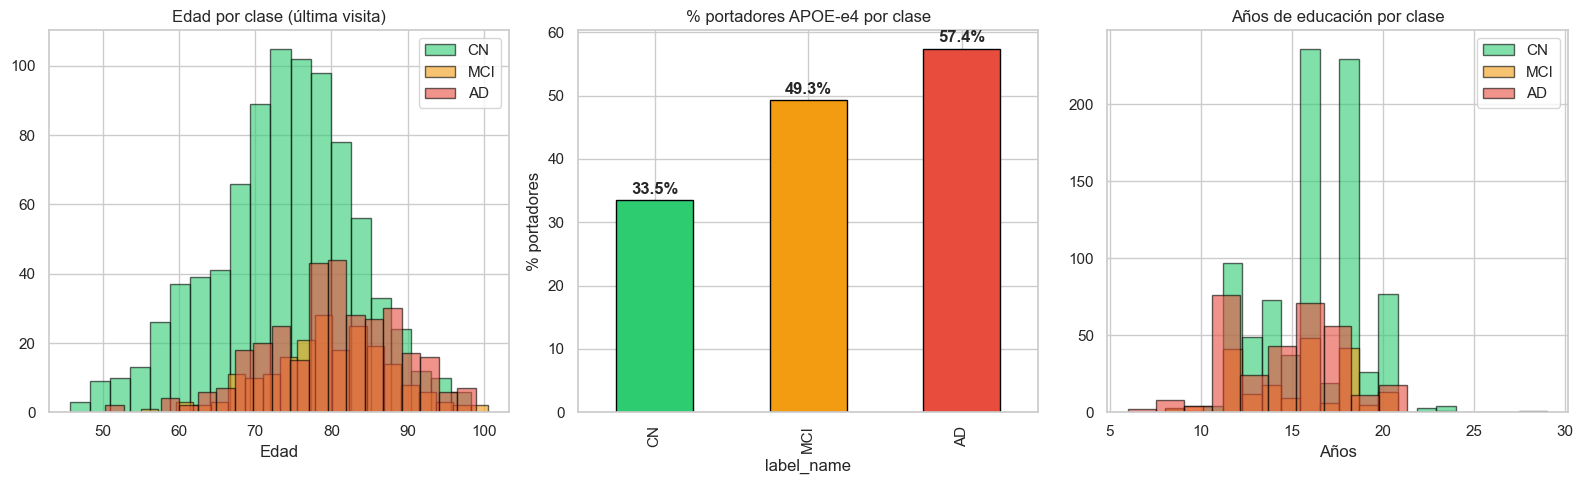

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a. Edad por clase (última evaluación)
for label, color in zip(['CN', 'MCI', 'AD'], colors):
    subset = df_last[df_last['label_name'] == label]['age at visit'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0].set_title('Edad por clase (última visita)')
axes[0].set_xlabel('Edad')
axes[0].legend()

# 7b. APOE-e4 por clase
apoe_by_class = df_last.groupby('label_name')['APOE_e4'].mean().reindex(['CN', 'MCI', 'AD']) * 100
apoe_by_class.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('% portadores APOE-e4 por clase')
axes[1].set_ylabel('% portadores')
for i, v in enumerate(apoe_by_class):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 7c. Educación por clase
for label, color in zip(['CN', 'MCI', 'AD'], colors):
    subset = df_last[df_last['label_name'] == label]['EDUC'].dropna()
    axes[2].hist(subset, bins=15, alpha=0.6, label=label, color=color, edgecolor='black')
axes[2].set_title('Años de educación por clase')
axes[2].set_xlabel('Años')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. MMSE por clase (marcador cognitivo)

C:\Users\alfre\AppData\Local\Temp\ipykernel_18912\2549082020.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mmse, x='label_name', y='MMSE', order=['CN', 'MCI', 'AD'],


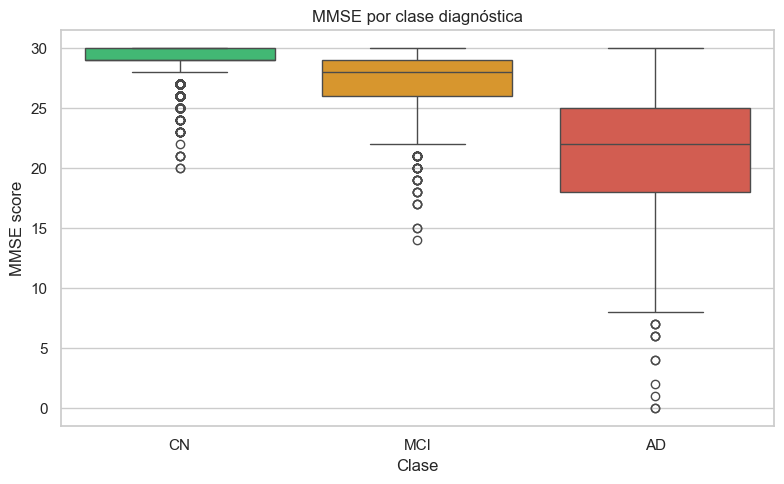

Estadísticas MMSE por clase:
             count       mean       std   min   25%   50%   75%   max
label_name                                                           
CN          5680.0  29.082218  1.228341  20.0  29.0  29.0  30.0  30.0
MCI         1319.0  27.087945  2.586559  14.0  26.0  28.0  29.0  30.0
AD           594.0  21.090909  5.202006   0.0  18.0  22.0  25.0  30.0


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

df_mmse = df_master.dropna(subset=['MMSE'])
sns.boxplot(data=df_mmse, x='label_name', y='MMSE', order=['CN', 'MCI', 'AD'],
            palette=colors, ax=ax)
ax.set_title('MMSE por clase diagnóstica')
ax.set_xlabel('Clase')
ax.set_ylabel('MMSE score')
plt.tight_layout()
plt.show()

print("Estadísticas MMSE por clase:")
print(df_mmse.groupby('label_name')['MMSE'].describe().loc[['CN', 'MCI', 'AD']])

## 9. Resumen y guardado

In [21]:
output_path = Path(r"d:\clase\tfg\data") / "oasis3_master_clinical.csv"
df_master.to_csv(output_path, index=False)

print("=" * 50)
print("RESUMEN DEL DATASET CLÍNICO OASIS-3")
print("=" * 50)
print(f"Pacientes únicos:     {df_master['OASISID'].nunique()}")
print(f"Evaluaciones totales: {len(df_master)}")
print(f"")
print(f"Distribución de clases (evaluaciones):")
for label in [0, 1, 2]:
    n = len(df_master[df_master['label'] == label])
    pct = n / len(df_master) * 100
    print(f"  {label} ({label_names[label]:>3}): {n:>5} ({pct:.1f}%)")
print(f"")
print(f"Distribución por paciente (última visita):")
for label in [0, 1, 2]:
    n = len(df_last[df_last['label'] == label])
    pct = n / len(df_last) * 100
    print(f"  {label} ({label_names[label]:>3}): {n:>4} ({pct:.1f}%)")
print(f"")
print(f"Guardado en: {output_path}")
print("=" * 50)

RESUMEN DEL DATASET CLÍNICO OASIS-3
Pacientes únicos:     1377
Evaluaciones totales: 8625

Distribución de clases (evaluaciones):
  0 ( CN):  6479 (75.1%)
  1 (MCI):  1444 (16.7%)
  2 ( AD):   702 (8.1%)

Distribución por paciente (última visita):
  0 ( CN):  857 (62.2%)
  1 (MCI):  203 (14.7%)
  2 ( AD):  317 (23.0%)

Guardado en: d:\clase\tfg\data\oasis3_master_clinical.csv


## 10. Comparativa OASIS-1 vs OASIS-3

In [22]:
# Comparación rápida con nuestro dataset actual
oasis1 = {'CN': 135, 'MCI': 70, 'AD': 30}  # 235 sujetos OASIS-1
oasis3_patients = patient_counts.to_dict()

comp = pd.DataFrame({
    'OASIS-1 (actual)': oasis1,
    'OASIS-3 (por paciente, última visita)': oasis3_patients
})
comp['Factor de aumento'] = (comp['OASIS-3 (por paciente, última visita)'] / comp['OASIS-1 (actual)']).round(1)

print("Comparativa de tamaños de dataset:")
print(comp.to_string())
print(f"\nTotal OASIS-1: {sum(oasis1.values())} sujetos")
print(f"Total OASIS-3: {len(df_last)} sujetos (con CDR válido)")
print(f"\nNOTA: Para usar OASIS-3 necesitamos vincular estos IDs con sesiones MRI disponibles.")

Comparativa de tamaños de dataset:
     OASIS-1 (actual)  OASIS-3 (por paciente, última visita)  Factor de aumento
CN                135                                    857                6.3
MCI                70                                    203                2.9
AD                 30                                    317               10.6

Total OASIS-1: 235 sujetos
Total OASIS-3: 1377 sujetos (con CDR válido)

NOTA: Para usar OASIS-3 necesitamos vincular estos IDs con sesiones MRI disponibles.


---

# Parte II — Match Temporal MRI-Clínico

Objetivo: alinear temporalmente cada sesión MR (scan cerebral) con la evaluación clínica más cercana, para obtener un dataset donde cada imagen tiene una etiqueta diagnóstica válida (CDR dentro de ±180 días).

## 11. Carga y filtrado de sesiones MR

In [23]:
import re

PATH_MR = Path(r"d:\clase\tfg\data\uo293619_3_10_2026_17_33_22.csv")
PATH_CLINICAL = Path(r"d:\clase\tfg\data\oasis3_master_clinical.csv")

df_mr_raw = pd.read_csv(PATH_MR, low_memory=False)
df_clinical = pd.read_csv(PATH_CLINICAL, low_memory=False)

print(f"MR sessions cargadas: {len(df_mr_raw)}")
print(f"Columnas MR: {list(df_mr_raw.columns)}")
df_mr_raw.head(3)

MR sessions cargadas: 2844
Columnas MR: ['MR ID', 'Date', 'Subject', 'Age', 'Scanner', 'Scans', 'PUP Timecourses', 'Freesurfers']


,MR ID,Date,Subject,Age,Scanner,Scans,PUP Timecourses,Freesurfers
0,OAS30001_MR_d0129,NaN,OAS30001,65.0,3.0T,"T1w(2), T2w(2), bold(3)",NaN,1.0
1,OAS30001_MR_d0757,NaN,OAS30001,67.0,3.0T,"T1w(2), T2star(1), T2w(2), bold(2), dwi(1), mi...",NaN,1.0
2,OAS30001_MR_d2430,NaN,OAS30001,71.0,3.0T,"FLAIR(1), T1w(1), T2star(1), T2w(1), angio(1),...",NaN,1.0


In [24]:
# Autodetectar la columna que contiene los IDs de sesión MR (patrón OAS3xxxx_MR_dXXXX)
mr_pattern = re.compile(r'OAS3\d+_MR_d\d+')
mr_id_col = None
for col in df_mr_raw.columns:
    if df_mr_raw[col].astype(str).str.match(mr_pattern).any():
        mr_id_col = col
        break

print(f"Columna con MR session IDs: '{mr_id_col}'")

# Filtrar solo sesiones con al menos una secuencia T1w
df_mr = df_mr_raw[df_mr_raw['Scans'].astype(str).str.contains('T1w', na=False)].copy()
print(f"Sesiones con T1w: {len(df_mr)} / {len(df_mr_raw)} ({len(df_mr)/len(df_mr_raw)*100:.1f}%)")
print(f"Descartadas (sin T1w): {len(df_mr_raw) - len(df_mr)}")

Columna con MR session IDs: 'MR ID'
Sesiones con T1w: 2832 / 2844 (99.6%)
Descartadas (sin T1w): 12


## 12. Parseo de sesiones MR

In [25]:
# Extraer OASISID y mr_days del campo MR ID
# Ejemplo: "OAS30001_MR_d0129" -> OASISID="OAS30001", mr_days=129
parsed = df_mr[mr_id_col].str.extract(r'(OAS3\d+)_MR_d(\d+)')
df_mr = df_mr.copy()
df_mr['OASISID'] = parsed[0]
df_mr['mr_days'] = parsed[1].astype(int)
df_mr['mr_session'] = df_mr[mr_id_col]

print(f"Sesiones parseadas: {len(df_mr)}")
print(f"Pacientes únicos con MR: {df_mr['OASISID'].nunique()}")
print(f"\nRango de mr_days: {df_mr['mr_days'].min()} — {df_mr['mr_days'].max()}")
print(f"Media de sesiones MR por paciente: {df_mr.groupby('OASISID').size().mean():.1f}")
df_mr[['mr_session', 'OASISID', 'mr_days', 'Scans', 'Scanner']].head()

Sesiones parseadas: 2832
Pacientes únicos con MR: 1376

Rango de mr_days: 0 — 9874
Media de sesiones MR por paciente: 2.1


,mr_session,OASISID,mr_days,Scans,Scanner
0,OAS30001_MR_d0129,OAS30001,129,"T1w(2), T2w(2), bold(3)",3.0T
1,OAS30001_MR_d0757,OAS30001,757,"T1w(2), T2star(1), T2w(2), bold(2), dwi(1), mi...",3.0T
2,OAS30001_MR_d2430,OAS30001,2430,"FLAIR(1), T1w(1), T2star(1), T2w(1), angio(1),...",3.0T
3,OAS30001_MR_d3132,OAS30001,3132,"T1w(1), T2star(1), T2w(2), asl(2), bold(2), dw...",3.0T
4,OAS30001_MR_d3746,OAS30001,3746,"FLAIR(1), T1w(1), T2star(1), T2w(1), angio(1),...",NaN


## 13. Match temporal (merge_asof, ventana ±180 días)

Cada sesión MR se empareja con la evaluación clínica **más cercana en el tiempo** del mismo paciente. Si la diferencia supera 180 días, se descarta.

In [27]:
TOLERANCE_DAYS = 180

# Preparar MR: solo las columnas necesarias
df_mr_clean = (
    df_mr[['OASISID', 'mr_days', 'mr_session', 'Scanner', 'Scans']]
    .copy()
)

# Asegurar tipos numéricos consistentes para merge_asof
df_mr_clean['mr_days'] = df_mr_clean['mr_days'].astype('int64')
df_clinical['days_to_visit'] = df_clinical['days_to_visit'].astype('int64')

# merge_asof por grupo: procesar cada paciente por separado
# (evita el requisito de orden global que falla con by + direction='nearest')
matched_parts = []
for oas_id, mr_group in df_mr_clean.groupby('OASISID'):
    clin_group = df_clinical[df_clinical['OASISID'] == oas_id]
    if clin_group.empty:
        continue
    mr_sorted = mr_group.sort_values('mr_days')
    clin_sorted = clin_group.sort_values('days_to_visit')
    merged = pd.merge_asof(
        mr_sorted, clin_sorted,
        left_on='mr_days', right_on='days_to_visit',
        by='OASISID', direction='nearest', tolerance=TOLERANCE_DAYS,
    )
    matched_parts.append(merged)

df_matched = pd.concat(matched_parts, ignore_index=True)

# Calcular diferencia temporal para inspección
df_matched['days_diff'] = (df_matched['mr_days'] - df_matched['days_to_visit']).abs()

# Eliminar filas sin match (fuera de la ventana de tolerancia)
n_total_mr = len(df_mr_clean)
n_before = len(df_matched)
df_matched = df_matched.dropna(subset=['days_to_visit']).copy()
df_matched['label'] = df_matched['label'].astype(int)
n_dropped = n_total_mr - len(df_matched)

print(f"Sesiones MR de entrada (con T1w): {n_total_mr}")
print(f"Match exitoso (±{TOLERANCE_DAYS} días):    {len(df_matched)}")
print(f"Descartadas (sin visita cercana):  {n_dropped}")
print(f"Tasa de match: {len(df_matched)/n_total_mr*100:.1f}%")

Sesiones MR de entrada (con T1w): 2832
Match exitoso (±180 días):    2450
Descartadas (sin visita cercana):  382
Tasa de match: 86.5%


## 14. Estadísticas del match

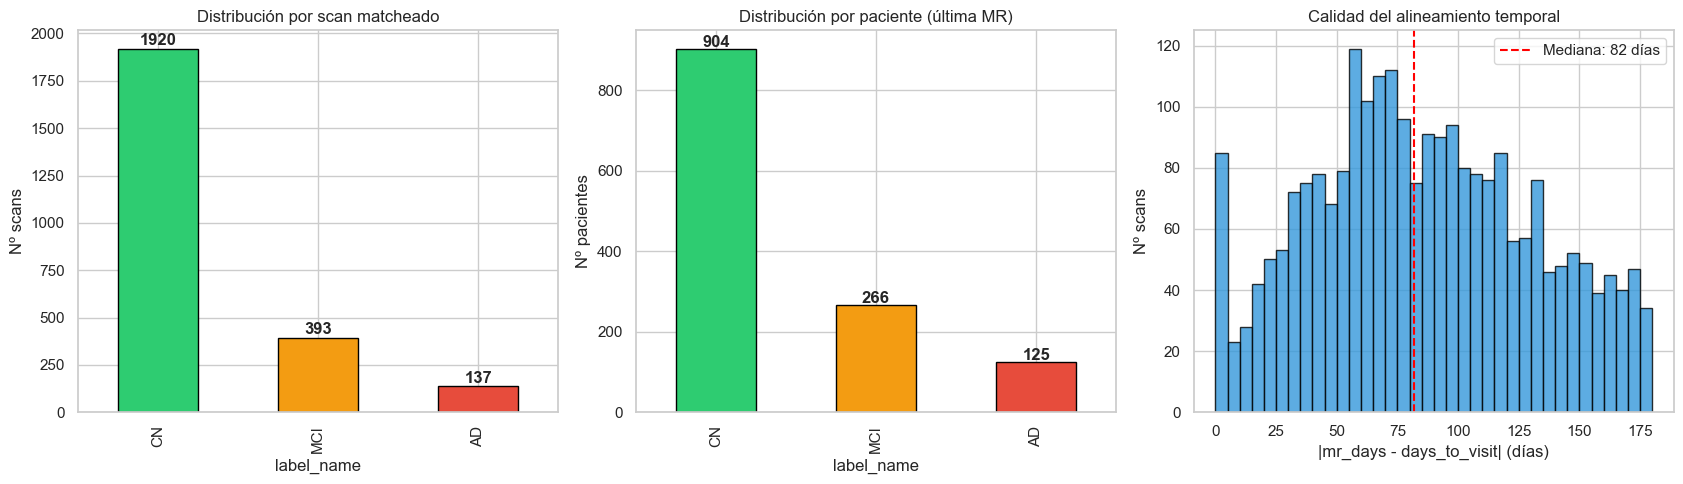

Diferencia temporal (días): media=85.1, mediana=82, max=180


In [28]:
label_names = {0: 'CN', 1: 'MCI', 2: 'AD'}
df_matched['label_name'] = df_matched['label'].map(label_names)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# 14a. Distribución de clases (scans matcheados)
scan_counts = df_matched['label_name'].value_counts().reindex(['CN', 'MCI', 'AD'])
scan_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribución por scan matcheado')
axes[0].set_ylabel('Nº scans')
for i, v in enumerate(scan_counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# 14b. Distribución por paciente único (última sesión MR)
df_last_mr = df_matched.sort_values('mr_days').groupby('OASISID').last().reset_index()
pat_counts = df_last_mr['label_name'].value_counts().reindex(['CN', 'MCI', 'AD'])
pat_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Distribución por paciente (última MR)')
axes[1].set_ylabel('Nº pacientes')
for i, v in enumerate(pat_counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 14c. Histograma de days_diff (calidad del alineamiento)
axes[2].hist(df_matched['days_diff'], bins=36, color='#3498db', edgecolor='black', alpha=0.8)
axes[2].axvline(x=df_matched['days_diff'].median(), color='red', linestyle='--',
                label=f"Mediana: {df_matched['days_diff'].median():.0f} días")
axes[2].set_title('Calidad del alineamiento temporal')
axes[2].set_xlabel('|mr_days - days_to_visit| (días)')
axes[2].set_ylabel('Nº scans')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Diferencia temporal (días): media={df_matched['days_diff'].mean():.1f}, "
      f"mediana={df_matched['days_diff'].median():.0f}, max={df_matched['days_diff'].max():.0f}")

In [29]:
# Comparativa con OASIS-1
oasis1 = {'CN': 135, 'MCI': 70, 'AD': 30}
oasis3_scans = scan_counts.to_dict()
oasis3_pats = pat_counts.to_dict()

comp = pd.DataFrame({
    'OASIS-1 (sujetos)': oasis1,
    'OASIS-3 scans matcheados': oasis3_scans,
    'OASIS-3 pacientes únicos': oasis3_pats,
})
comp['Factor (scans vs OASIS-1)'] = (comp['OASIS-3 scans matcheados'] / comp['OASIS-1 (sujetos)']).round(1)

print("Comparativa OASIS-1 vs OASIS-3 (matcheado):")
print(comp.to_string())
print(f"\nTotal OASIS-1: {sum(oasis1.values())} sujetos")
print(f"Total OASIS-3: {len(df_matched)} scans matcheados de {df_matched['OASISID'].nunique()} pacientes")

Comparativa OASIS-1 vs OASIS-3 (matcheado):
     OASIS-1 (sujetos)  OASIS-3 scans matcheados  OASIS-3 pacientes únicos  Factor (scans vs OASIS-1)
CN                 135                      1920                       904                       14.2
MCI                 70                       393                       266                        5.6
AD                  30                       137                       125                        4.6

Total OASIS-1: 235 sujetos
Total OASIS-3: 2450 scans matcheados de 1295 pacientes


## 15. Guardado de resultados

In [30]:
OUT_DIR = Path(r"d:\clase\tfg\data\processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset completo matcheado
matched_path = OUT_DIR / "oasis3_matched_dataset.csv"
df_matched.to_csv(matched_path, index=False)
print(f"Dataset completo guardado: {matched_path}")
print(f"  {len(df_matched)} filas, {len(df_matched.columns)} columnas")

# Toy subset: 10 filas aleatorias para test de descarga
np.random.seed(42)
df_sample = df_matched.sample(n=min(10, len(df_matched)), random_state=42)
download_test_path = OUT_DIR / "download_test_10.csv"
df_sample[['mr_session']].to_csv(download_test_path, index=False)
print(f"\nSubset de test guardado: {download_test_path}")
print(f"  Sesiones para descargar:")
for s in df_sample['mr_session'].values:
    print(f"    {s}")

# Resumen final
print(f"\n{'='*50}")
print(f"RESUMEN FINAL — MATCH MRI-CLÍNICO OASIS-3")
print(f"{'='*50}")
print(f"Sesiones MR totales:          {len(df_mr_raw)}")
print(f"Con T1w:                      {len(df_mr)}")
print(f"Match exitoso (±{TOLERANCE_DAYS}d):       {len(df_matched)}")
print(f"Pacientes únicos matcheados:  {df_matched['OASISID'].nunique()}")
print(f"")
print(f"Distribución de clases (scans):")
for lbl in [0, 1, 2]:
    n = len(df_matched[df_matched['label'] == lbl])
    pct = n / len(df_matched) * 100
    print(f"  {lbl} ({label_names[lbl]:>3}): {n:>5} ({pct:.1f}%)")
print(f"{'='*50}")

Dataset completo guardado: d:\clase\tfg\data\processed\oasis3_matched_dataset.csv
  2450 filas, 27 columnas

Subset de test guardado: d:\clase\tfg\data\processed\download_test_10.csv
  Sesiones para descargar:
    OAS30709_MR_d1365
    OAS30535_MR_d1329
    OAS31371_MR_d0167
    OAS30335_MR_d3812
    OAS30321_MR_d3003
    OAS30786_MR_d3713
    OAS30794_MR_d1680
    OAS31090_MR_d0833
    OAS31001_MR_d1079
    OAS31388_MR_d0026

RESUMEN FINAL — MATCH MRI-CLÍNICO OASIS-3
Sesiones MR totales:          2844
Con T1w:                      2832
Match exitoso (±180d):       2450
Pacientes únicos matcheados:  1295

Distribución de clases (scans):
  0 ( CN):  1920 (78.4%)
  1 (MCI):   393 (16.0%)
  2 ( AD):   137 (5.6%)


---

# Parte III — Split Train/Val/Test (Anti-Leakage)

Objetivo: cruzar los NIfTI T1w descargados con el ground truth clínico y generar los CSVs de split listos para `src/dataset.py`.

**Clave**: el split se hace a nivel de **paciente** (GroupShuffleSplit), no de imagen. Un paciente con múltiples sesiones MR estará completo en un solo split, evitando data leakage.

## 16. Escanear NIfTIs descargados y parsear estructura BIDS

In [3]:
import os
import glob
import re
from sklearn.model_selection import GroupShuffleSplit

OASIS3_IMG_DIR = Path(r"d:\clase\tfg\data\OASIS-3")
MATCHED_CSV = Path(r"d:\clase\tfg\data\processed\oasis3_matched_dataset.csv")
SPLITS_DIR = Path(r"d:\clase\tfg\data\splits")

print("Buscando NIfTIs T1w en estructura BIDS...")
nifti_files = glob.glob(str(OASIS3_IMG_DIR / "**" / "*T1w.nii.gz"), recursive=True)
print(f"Archivos T1w encontrados: {len(nifti_files)}")

# Parsear las rutas BIDS para extraer OASISID y mr_days
# Formato: sub-OAS30001_ses-d0129_run-01_T1w.nii.gz
#       o: sub-OAS30001_sess-d3746_T1w.nii.gz
data_list = []
parse_errors = 0
for path in nifti_files:
    filename = os.path.basename(path)
    parts = filename.split('_')

    sub_parts = [p.replace('sub-', '') for p in parts if p.startswith('sub-')]
    ses_parts = [p for p in parts if p.startswith('ses')]

    if not sub_parts or not ses_parts:
        parse_errors += 1
        continue

    sub_id = sub_parts[0]
    # Manejar tanto "ses-d0129" como "sess-d3746"
    ses_str = ses_parts[0]
    day_match = re.search(r'd(\d+)', ses_str)
    if not day_match:
        parse_errors += 1
        continue

    data_list.append({
        'OASISID': sub_id,
        'mr_days': int(day_match.group(1)),
        'image_path': os.path.abspath(path),
        'filename': filename,
    })

df_images = pd.DataFrame(data_list)
print(f"NIfTIs parseados correctamente: {len(df_images)}")
if parse_errors > 0:
    print(f"Errores de parseo (descartados): {parse_errors}")

# Filtro de runs: si hay múltiples runs por sesión, quedarse con el primero
n_before = len(df_images)
df_images = df_images.sort_values(by=['OASISID', 'mr_days', 'filename'])
df_images = df_images.drop_duplicates(subset=['OASISID', 'mr_days'], keep='first')
print(f"Imágenes únicas por sesión (tras eliminar runs extra): {len(df_images)} (de {n_before})")
print(f"Pacientes únicos con imágenes: {df_images['OASISID'].nunique()}")

df_images.head()

Buscando NIfTIs T1w en estructura BIDS...
Archivos T1w encontrados: 3495
NIfTIs parseados correctamente: 3495
Imágenes únicas por sesión (tras eliminar runs extra): 2450 (de 3495)
Pacientes únicos con imágenes: 1295


,OASISID,mr_days,image_path,filename
0,OAS30001,129,d:\clase\tfg\data\OASIS-3\sub-OAS30001\ses-d01...,sub-OAS30001_ses-d0129_run-01_T1w.nii.gz
2,OAS30001,757,d:\clase\tfg\data\OASIS-3\sub-OAS30001\ses-d07...,sub-OAS30001_ses-d0757_run-01_T1w.nii.gz
4,OAS30001,3132,d:\clase\tfg\data\OASIS-3\sub-OAS30001\ses-d31...,sub-OAS30001_ses-d3132_T1w.nii.gz
5,OAS30001,3746,d:\clase\tfg\data\OASIS-3\sub-OAS30001\ses-d37...,sub-OAS30001_sess-d3746_T1w.nii.gz
6,OAS30001,4467,d:\clase\tfg\data\OASIS-3\sub-OAS30001\ses-d44...,sub-OAS30001_sess-d4467_T1w.nii.gz


## 17. Cruzar NIfTIs con ground truth clínico

Ground truth cargado: 2450 filas, 1295 pacientes

Imágenes con etiqueta clínica válida: 2450
Pacientes únicos: 1295

Imágenes sin match (descartadas): 0

Distribución de clases:
  0 ( CN):  1920 imágenes (78.4%)
  1 (MCI):   393 imágenes (16.0%)
  2 ( AD):   137 imágenes (5.6%)


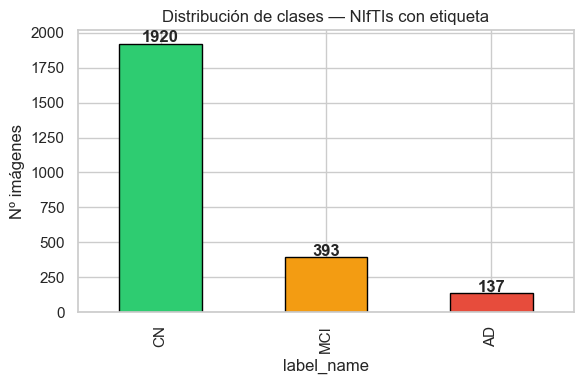

In [4]:
df_ground_truth = pd.read_csv(MATCHED_CSV)
print(f"Ground truth cargado: {len(df_ground_truth)} filas, {df_ground_truth['OASISID'].nunique()} pacientes")

# Cruzar por paciente + día del escáner
df_final = pd.merge(
    df_images[['OASISID', 'mr_days', 'image_path']],
    df_ground_truth[['OASISID', 'mr_days', 'label', 'label_name', 'CDRTOT', 'age at visit', 'GENDER']],
    on=['OASISID', 'mr_days'],
    how='inner',
)

print(f"\nImágenes con etiqueta clínica válida: {len(df_final)}")
print(f"Pacientes únicos: {df_final['OASISID'].nunique()}")
print(f"\nImágenes sin match (descartadas): {len(df_images) - len(df_final)}")

# Distribución de clases
print(f"\nDistribución de clases:")
label_names = {0: 'CN', 1: 'MCI', 2: 'AD'}
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for lbl in [0, 1, 2]:
    n = len(df_final[df_final['label'] == lbl])
    pct = n / len(df_final) * 100
    print(f"  {lbl} ({label_names[lbl]:>3}): {n:>5} imágenes ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
counts = df_final['label_name'].value_counts().reindex(['CN', 'MCI', 'AD'])
counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribución de clases — NIfTIs con etiqueta')
ax.set_ylabel('Nº imágenes')
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 18. Subject-Level Split (Anti-Leakage)

Split 70% train / 15% val / 15% test **a nivel de paciente** usando `GroupShuffleSplit`. Esto garantiza que todas las sesiones MR de un mismo paciente caen en el mismo split.

In [5]:
# Preparar DataFrame con formato compatible con src/dataset.py
df_split = df_final.rename(columns={'OASISID': 'subject_id'})
df_split = df_split[['subject_id', 'image_path', 'label']].copy()

# Split 1: 85% train+val, 15% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss1.split(df_split, groups=df_split['subject_id']))

df_train_val = df_split.iloc[train_val_idx].reset_index(drop=True)
df_test = df_split.iloc[test_idx].reset_index(drop=True)

# Split 2: del 85% restante, separar ~17.6% para val (~15% global)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss2.split(df_train_val, groups=df_train_val['subject_id']))

df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
df_val = df_train_val.iloc[val_idx].reset_index(drop=True)

print("=" * 60)
print("DISTRIBUCIÓN FINAL")
print("=" * 60)

for name, df_s in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    n_patients = df_s['subject_id'].nunique()
    n_images = len(df_s)
    print(f"\n  {name}: {n_patients} pacientes | {n_images} imágenes")
    for lbl in [0, 1, 2]:
        n = len(df_s[df_s['label'] == lbl])
        pct = n / n_images * 100 if n_images > 0 else 0
        print(f"    {lbl} ({label_names[lbl]:>3}): {n:>4} ({pct:.1f}%)")

print(f"\n  TOTAL: {df_split['subject_id'].nunique()} pacientes | {len(df_split)} imágenes")

DISTRIBUCIÓN FINAL

  TRAIN: 906 pacientes | 1731 imágenes
    0 ( CN): 1372 (79.3%)
    1 (MCI):  276 (15.9%)
    2 ( AD):   83 (4.8%)

  VAL: 194 pacientes | 369 imágenes
    0 ( CN):  287 (77.8%)
    1 (MCI):   58 (15.7%)
    2 ( AD):   24 (6.5%)

  TEST: 195 pacientes | 350 imágenes
    0 ( CN):  261 (74.6%)
    1 (MCI):   59 (16.9%)
    2 ( AD):   30 (8.6%)

  TOTAL: 1295 pacientes | 2450 imágenes


## 19. Verificación anti-leakage y guardado de CSVs

In [6]:
# Verificación anti-leakage: ningún paciente debe aparecer en más de un split
train_ids = set(df_train['subject_id'])
val_ids = set(df_val['subject_id'])
test_ids = set(df_test['subject_id'])

leak_tv = train_ids & val_ids
leak_tt = train_ids & test_ids
leak_vt = val_ids & test_ids

print("VERIFICACIÓN ANTI-LEAKAGE")
print("=" * 40)
if leak_tv or leak_tt or leak_vt:
    print("[FAIL] Data leakage detectado:")
    if leak_tv: print(f"  Train & Val:  {len(leak_tv)} pacientes")
    if leak_tt: print(f"  Train & Test: {len(leak_tt)} pacientes")
    if leak_vt: print(f"  Val & Test:   {len(leak_vt)} pacientes")
else:
    print("[PASS] 0 pacientes compartidos entre splits")

# Verificar que la imagen existe en disco (sample rápido)
sample_paths = df_train['image_path'].sample(min(5, len(df_train)), random_state=42)
missing = [p for p in sample_paths if not os.path.exists(p)]
if missing:
    print(f"\n[WARN] {len(missing)} imágenes de muestra no encontradas en disco")
else:
    print(f"[PASS] Verificación de archivos OK (5 muestras existen en disco)")

# Guardar CSVs
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

df_train.to_csv(SPLITS_DIR / "oasis3_train.csv", index=False)
df_val.to_csv(SPLITS_DIR / "oasis3_val.csv", index=False)
df_test.to_csv(SPLITS_DIR / "oasis3_test.csv", index=False)

print(f"\nCSVs guardados en {SPLITS_DIR}/:")
print(f"  oasis3_train.csv  ({len(df_train)} filas)")
print(f"  oasis3_val.csv    ({len(df_val)} filas)")
print(f"  oasis3_test.csv   ({len(df_test)} filas)")
print(f"\nFormato compatible con src/dataset.py (columnas: subject_id, image_path, label)")

VERIFICACIÓN ANTI-LEAKAGE
[PASS] 0 pacientes compartidos entre splits
[PASS] Verificación de archivos OK (5 muestras existen en disco)

CSVs guardados en d:\clase\tfg\data\splits/:
  oasis3_train.csv  (1731 filas)
  oasis3_val.csv    (369 filas)
  oasis3_test.csv   (350 filas)

Formato compatible con src/dataset.py (columnas: subject_id, image_path, label)
